# Imports and cleaning

In [12]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from math import pi
import warnings
warnings.filterwarnings('ignore')


%matplotlib inline
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")

In [13]:
# ── Config ────────────────────────────────────────────────────────────────────
RESULTS_FILE = "evaluation_results.json"

TECHNIQUES  = ["zero_shot", "cot", "guided_cot", "tot", "got"]
CATEGORIES  = ["simple", "medium", "hard"]
TECH_LABELS = {
    "zero_shot"  : "Zero-Shot",
    "cot"        : "CoT",
    "guided_cot" : "Guided CoT",
    "tot"        : "ToT",
    "got"        : "GoT"
}
COLORS = {
    "zero_shot"  : "#4C72B0",
    "cot"        : "#DD8452",
    "guided_cot" : "#55A868",
    "tot"        : "#C44E52",
    "got"        : "#8172B3"
}
CAT_COLORS = {"simple": "#2ecc71", "medium": "#f39c12", "hard": "#e74c3c"}

In [14]:
# ── Load Data ─────────────────────────────────────────────────────────────────
with open(RESULTS_FILE, "r") as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
df["category"] = df["image_id"].apply(lambda x: x.split("_")[0])
df["img_num"]  = df["image_id"].apply(lambda x: int(x.split("_")[1]))
df["label"]    = df["technique"].map(TECH_LABELS)
df["notes"] = df["notes"].replace("", "None")

print(f"Loaded {len(df)} evaluation records")
df.fillna(0, inplace=True)
df.head()

Loaded 75 evaluation records


,image_id,technique,evaluator,file,timestamp,total_steps,total_features,addressed,fcr,scs,wr,roa,orr,wqs,notes,category,img_num,label
0,simple_1,zero_shot,Arya,output/zero_shot_results\result_simple_1_20260...,2026-02-25 00:27:30,5,3,3,1.0,1.0,1.00,0.0,0.0000,1.0000,None,simple,1,Zero-Shot
1,simple_1,cot,Arya,output/cot_results\result_simple_1_20260219_15...,2026-02-25 13:44:29,5,3,3,1.0,1.0,1.00,1.0,0.0000,1.0000,None,simple,1,CoT
2,simple_1,guided_cot,Arya,output/guided_cot_results\result_simple_1_2026...,2026-02-25 13:59:54,6,3,3,1.0,1.0,1.00,1.0,0.1667,0.8333,Extra: Chamfering,simple,1,Guided CoT
3,simple_1,tot,Arya,output/tot_results\result_simple_1_20260219_17...,2026-02-25 14:01:58,9,3,3,1.0,0.5,0.25,0.5,0.1111,0.3778,Wrong Orientation,simple,1,ToT
4,simple_1,got,Arya,output/got_results\result_simple_1_20260219_19...,2026-02-25 14:02:56,6,3,3,1.0,1.0,0.75,1.0,0.1667,0.7708,Extra: Chamfering,simple,1,GoT


# Plots

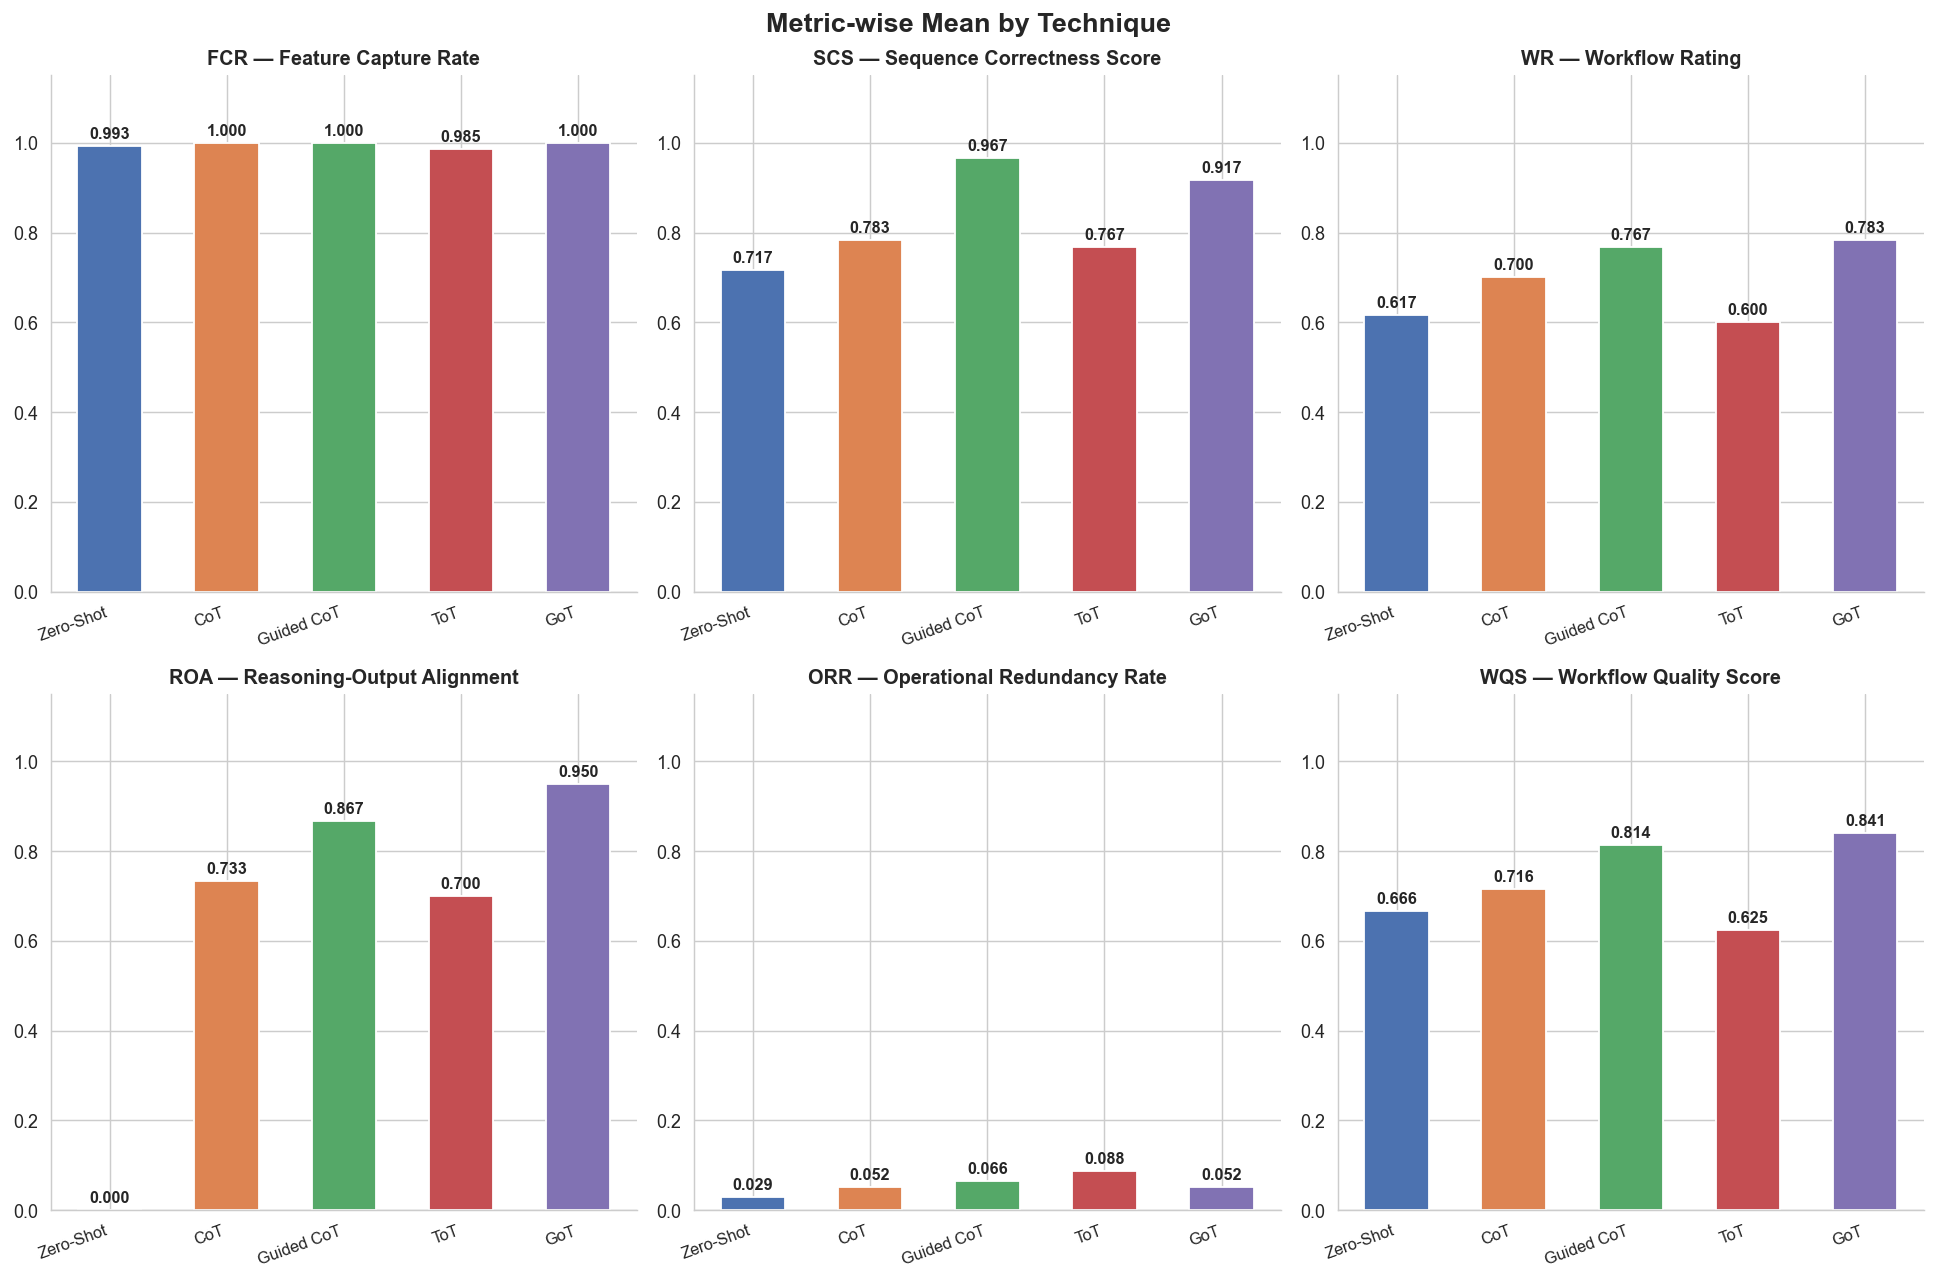

In [15]:
metrics = ["fcr", "scs", "wr", "roa", "orr", "wqs"]
metric_labels = [
    "FCR — Feature Capture Rate",
    "SCS — Sequence Correctness Score",
    "WR — Workflow Rating",
    "ROA — Reasoning-Output Alignment",
    "ORR — Operational Redundancy Rate",
    "WQS — Workflow Quality Score"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, metric, label in zip(axes, metrics, metric_labels):
    means = [df[df["technique"] == t][metric].mean() for t in TECHNIQUES]
    bars  = ax.bar(
        [TECH_LABELS[t] for t in TECHNIQUES],
        means,
        color=[COLORS[t] for t in TECHNIQUES],
        edgecolor="white", width=0.55
    )
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{mean:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.set_xticklabels([TECH_LABELS[t] for t in TECHNIQUES], rotation=20, ha="right", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Metric-wise Mean by Technique", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

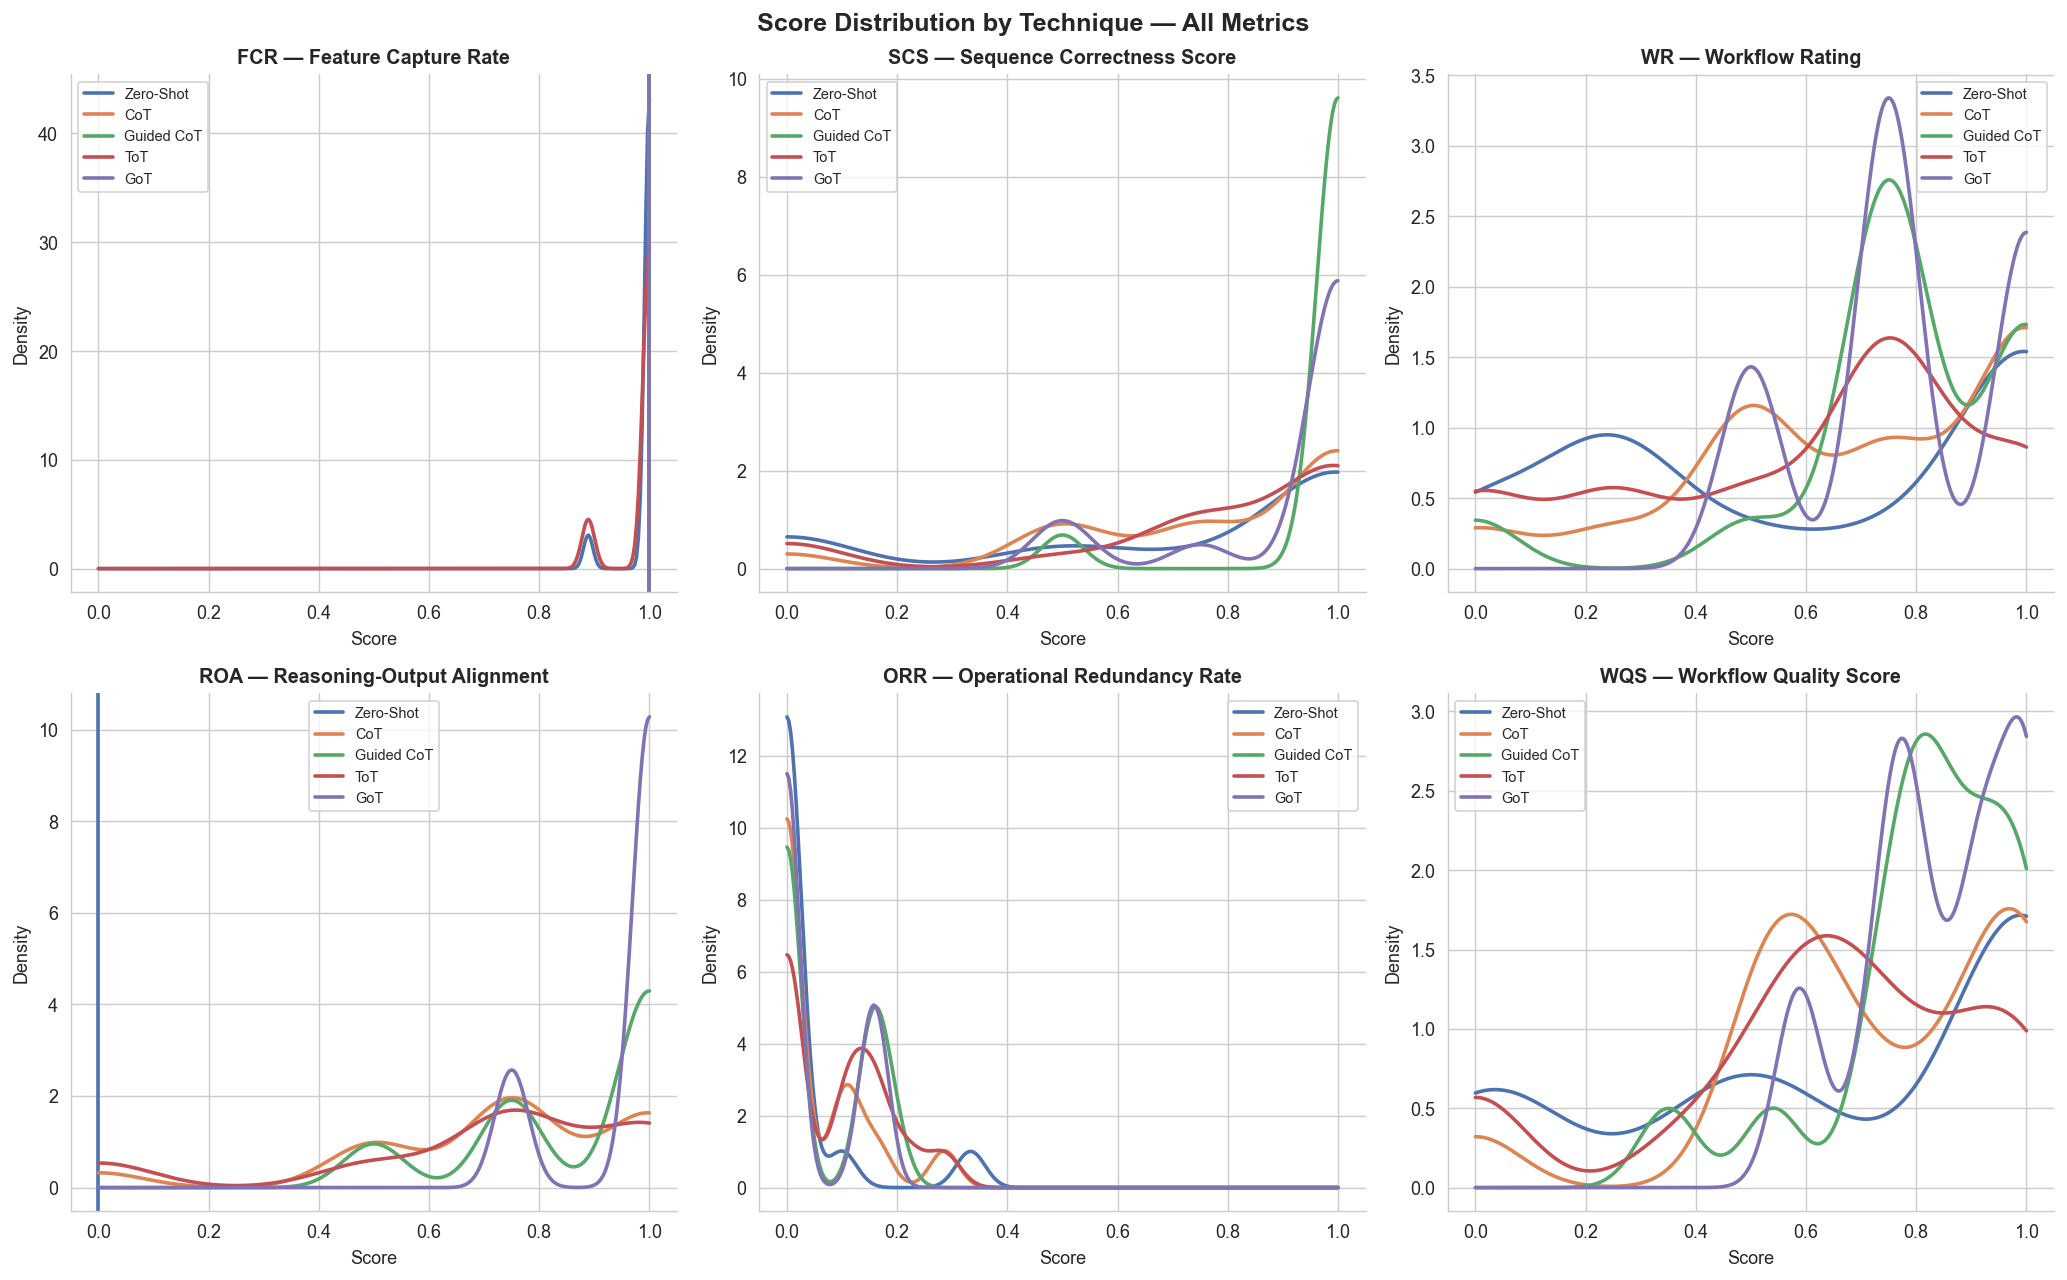

In [22]:
from scipy.stats import gaussian_kde

metrics = ["fcr", "scs", "wr", "roa", "orr", "wqs"]
metric_labels = [
    "FCR — Feature Capture Rate",
    "SCS — Sequence Correctness Score",
    "WR — Workflow Rating",
    "ROA — Reasoning-Output Alignment",
    "ORR — Operational Redundancy Rate",
    "WQS — Workflow Quality Score"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, metric, label in zip(axes, metrics, metric_labels):
    for t in TECHNIQUES:
        vals = df[df["technique"] == t][metric].dropna().values
        if len(np.unique(vals)) < 2:
            ax.axvline(vals[0], color=COLORS[t], linewidth=2, label=TECH_LABELS[t])
            continue
        try:
            kde = gaussian_kde(vals, bw_method=0.3)
            xs  = np.linspace(0, 1, 300)
            ax.plot(xs, kde(xs), label=TECH_LABELS[t], color=COLORS[t], linewidth=2)
            # ax.fill_between(xs, kde(xs), alpha=0.08, color=COLORS[t])
        except np.linalg.LinAlgError:
            ax.axvline(np.mean(vals), color=COLORS[t], linewidth=2, label=TECH_LABELS[t])

    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Score", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.set_xlim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Score Distribution by Technique — All Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

* FCR — All techniques reliably capture geometric features; FCR is not a differentiating factor.
* SCS — Guided CoT produces the most consistently correct machining sequences; other techniques show higher variance.
* WR — Workflow Rating has the highest variance across all techniques, making it the most discriminating metric.
* ROA — GoT reasoning most consistently aligns with output steps; CoT and ToT show bimodal behavior — reasoning helps only sometimes.
* ORR — Redundancy is uniformly low across all techniques; over-generation is not a systemic issue.
* WQS — GoT and Guided CoT show right-skewed distributions indicating consistently high quality; ToT and Zero-Shot are spread around mid-range scores.

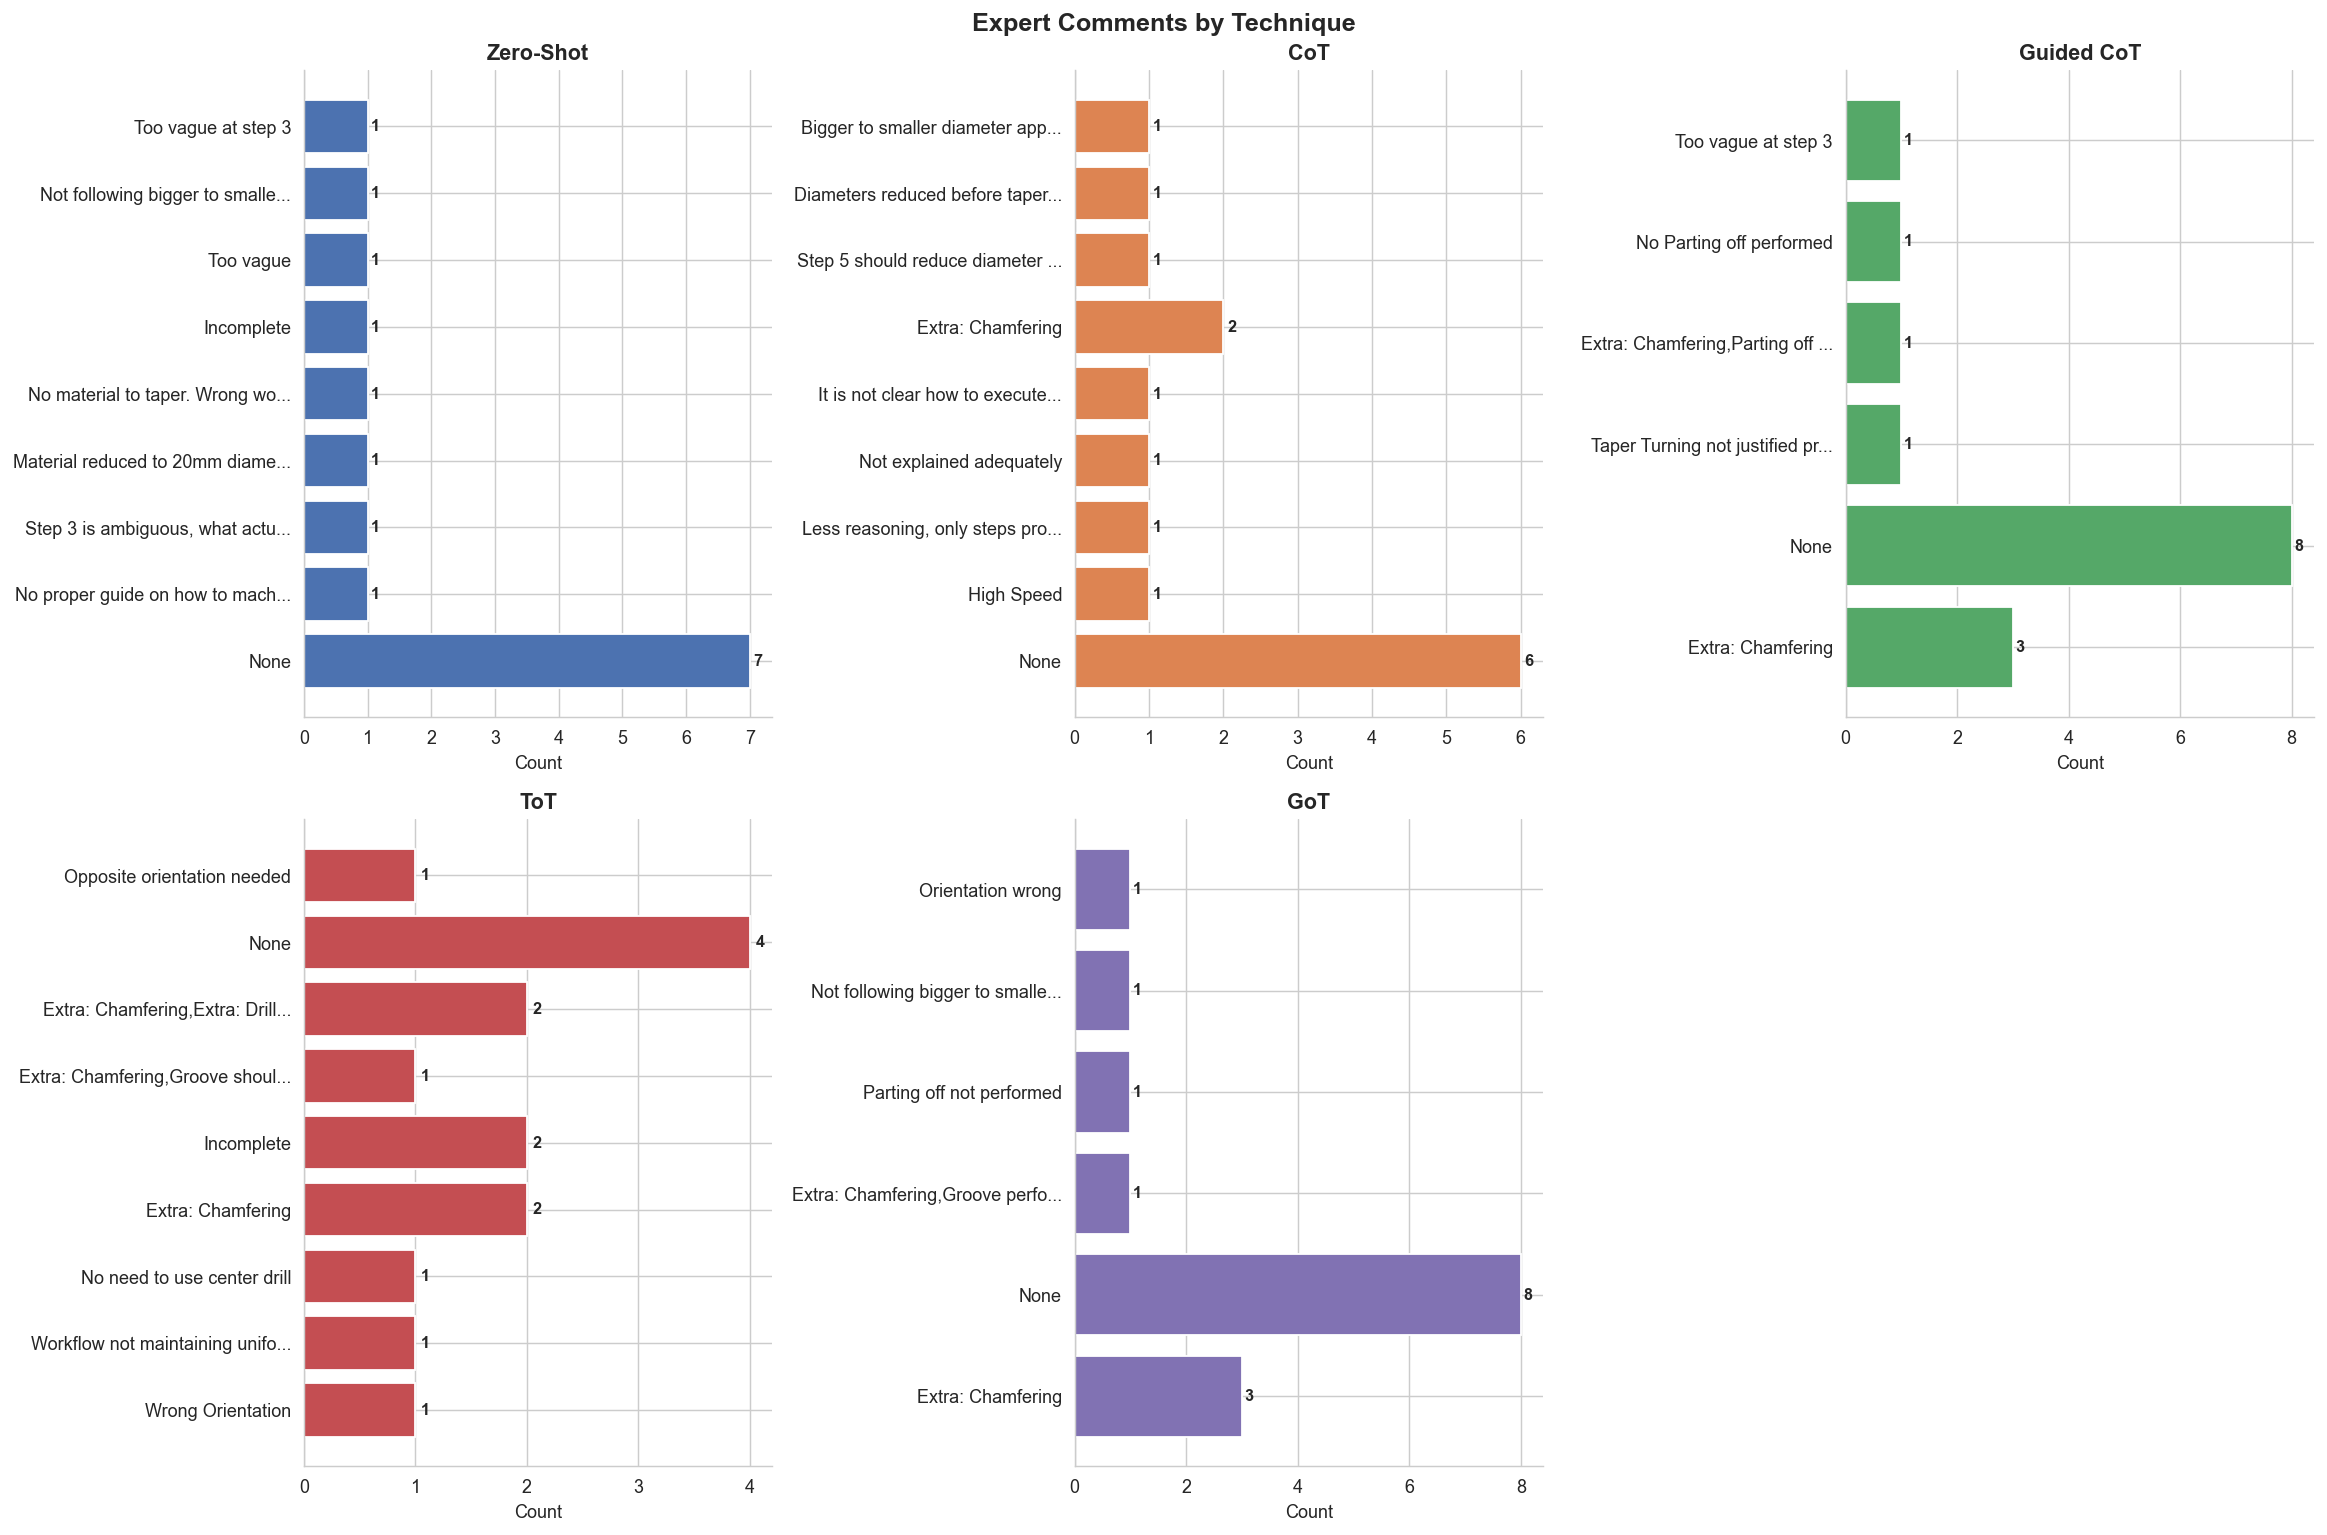

In [21]:
from collections import Counter

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, t in zip(axes, TECHNIQUES):
    notes = df[(df["technique"] == t) & (df["notes"] != 0) & (df["notes"].notna())]["notes"]
    if len(notes) == 0:
        ax.text(0.5, 0.5, "No comments", ha="center", va="center", fontsize=12)
        ax.set_title(TECH_LABELS[t], fontsize=12, fontweight="bold")
        continue

    counts = Counter(notes)
    labels = [k[:30] + "..." if len(k) > 30 else k for k in counts.keys()]
    values = list(counts.values())

    bars = ax.barh(labels, values, color=COLORS[t], edgecolor="white")
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                str(val), va="center", fontsize=9, fontweight="bold")

    ax.set_title(TECH_LABELS[t], fontsize=12, fontweight="bold")
    ax.set_xlabel("Count", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

# hide last unused subplot
axes[-1].set_visible(False)

fig.suptitle("Expert Comments by Technique", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

* Zero-Shot prompting produces fewer but vaguer steps — it rarely hallucinates extra operations (e.g. chamfering) but frequently under-specifies or misses machining logic.
* Reasoning-based techniques (CoT, Guided CoT, ToT, GoT) produce more detailed workflows but tend to over-generate — adding operations like chamfering that are not present in the drawing. This is reflected in their higher ORR values.

In [26]:
# from scipy.stats import kruskal
# import scikit_posthocs as sp

# # ── Kruskal-Wallis ────────────────────────────────────────────────────────────
# groups = [df[df["technique"] == t]["wqs"].values for t in TECHNIQUES]
# stat, p = kruskal(*groups)

# print("=" * 50)
# print("  KRUSKAL-WALLIS TEST — WQS")
# print("=" * 50)
# print(f"  H-statistic : {stat:.4f}")
# print(f"  p-value     : {p:.4f}")
# if p < 0.05:
#     print("  ✓ Significant difference exists between techniques (p < 0.05)")
# else:
#     print("  ✗ No significant difference found (p >= 0.05)")

# # ── Dunn's Post-hoc Test ──────────────────────────────────────────────────────
# dunn = sp.posthoc_dunn(df, val_col="wqs", group_col="technique", p_adjust="bonferroni")
# dunn.columns = [TECH_LABELS[t] for t in dunn.columns]
# dunn.index   = [TECH_LABELS[t] for t in dunn.index]

# print("\n  DUNN'S POST-HOC TEST — p-values")
# print("  (< 0.05 = significantly different pair)\n")
# print(dunn.round(4).to_string())

# # ── Heatmap of p-values ───────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(8, 6))
# im = ax.imshow(dunn.values, cmap="RdYlGn_r", vmin=0, vmax=0.1)

# ax.set_xticks(range(len(dunn.columns)))
# ax.set_xticklabels(dunn.columns, rotation=30, ha="right", fontsize=11)
# ax.set_yticks(range(len(dunn.index)))
# ax.set_yticklabels(dunn.index, fontsize=11)

# for i in range(len(dunn.index)):
#     for j in range(len(dunn.columns)):
#         val = dunn.values[i, j]
#         sig = "✓" if val < 0.05 else ""
#         ax.text(j, i, f"{val:.3f}\n{sig}", ha="center", va="center",
#                 fontsize=9, fontweight="bold",
#                 color="white" if val < 0.03 else "black")

# plt.colorbar(im, ax=ax, label="p-value")
# ax.set_title("Dunn's Test — Pairwise p-values\n(✓ = significantly different, green = more significant)",
#              fontsize=12, fontweight="bold")
# plt.tight_layout()
# plt.show()